In [2]:

import torch

# Check if CUDA is available
device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')
print(f"Using device = {torch.get_default_device()}")

Using device = cpu


In [3]:

import string
import unicodedata

# We can use "_" to represent an out-of-vocabulary character, that is, any character we are not handling in our model
allowed_characters = string.ascii_letters + " .,;'" + "_"
n_letters = len(allowed_characters)

# Turn a Unicode string to plain ASCII, thanks to https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in allowed_characters
    )

In [4]:
print (f"converting 'ŚlusfAR&&2A' to {unicodeToAscii('ŚlusfAR&&2A')}")

converting 'ŚlusfAR&&2A' to SlusfARA


In [5]:
# Find letter index from all_letters, e.g. "a" = 0
def letterToIndex(letter):
    # return our out-of-vocabulary character if we encounter a letter unknown to our model
    if letter not in allowed_characters:
        return allowed_characters.find("_")
    else:
        return allowed_characters.find(letter)

# Turn a line into a <line_length x 1 x n_letters>,
# or an array of one-hot letter vectors
def lineToTensor(line):
    tensor = torch.zeros(len(line), n_letters)
    for li, letter in enumerate(line):
        tensor[li][letterToIndex(letter)] = 1
    return tensor

In [6]:
from io import open
import glob
import os
import time
from torch.nn.utils.rnn import pad_sequence
from torch.nn.utils.rnn import pack_padded_sequence


import torch
from torch.utils.data import Dataset

class NamesDataset(Dataset):

    def __init__(self, data_dir):
        self.data_dir = data_dir #for provenance of the dataset
        self.load_time = time.localtime #for provenance of the dataset
        labels_set = set() #set of all classes

        self.data = []
        self.data_tensors = []
        self.labels = []
        self.labels_tensors = []

        #read all the ``.txt`` files in the specified directory
        text_files = glob.glob(os.path.join(data_dir, '*.txt'))
        for filename in text_files:
            label = os.path.splitext(os.path.basename(filename))[0]
            labels_set.add(label)
            lines = open(filename, encoding='utf-8').read().strip().split('\n')
            for name in lines:
                self.data.append(name)
                self.data_tensors.append(lineToTensor(name))
                self.labels.append(label)

        #Cache the tensor representation of the labels
        self.labels_uniq = list(labels_set)
        for idx in range(len(self.labels)):
            temp_tensor = torch.tensor([self.labels_uniq.index(self.labels[idx])], dtype=torch.long)
            self.labels_tensors.append(temp_tensor)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        data_item = self.data[idx]
        data_label = self.labels[idx]
        data_tensor = self.data_tensors[idx]
        label_tensor = self.labels_tensors[idx]

        return label_tensor, data_tensor, data_label, data_item
    def collate_fn(batch):
        label_tensors, data_tensors, data_labels, data_items = zip(*batch)
        lengths = torch.tensor([t.shape[0] for t in data_tensors])

        padded_sequences = pad_sequence(
            data_tensors,
            batch_first=True
        )

        labels = torch.cat(label_tensors)

        return padded_sequences, lengths, labels, data_labels, data_items

In [7]:
alldata = NamesDataset("data/names")
print(f"loaded {len(alldata)} items of data")
print(f"example = {alldata[0]}")

loaded 20074 items of data
example = (tensor([4]), tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

In [8]:
train_set, test_set = torch.utils.data.random_split(alldata, [.85, .15], generator=torch.Generator().manual_seed(2024))

print(f"train examples = {len(train_set)}, validation examples = {len(test_set)}")

train examples = 17063, validation examples = 3011


In [9]:
import torch.nn as nn
import torch.nn.functional as F

class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharRNN, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_size,batch_first = True)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)
        self.dropout = nn.Dropout(0.4)

    def forward(self, line_tensor,lengths):
        packed = pack_padded_sequence(
            line_tensor,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )
        rnn_out, hidden = self.rnn(packed)
        hidden = self.dropout(hidden[0])
        output = self.h2o(hidden)
        output = self.softmax(output)

        return output

In [11]:
def label_from_output(output, output_labels):
    top_n, top_i = output.topk(1)
    label_i = top_i[0].item()
    return output_labels[label_i], label_i

In [12]:
from torch.utils.data import Dataset, DataLoader

loader = DataLoader(
    train_set,
    batch_size=32,
    shuffle=True,
    collate_fn=NamesDataset.collate_fn
)
val_loader = DataLoader(
    test_set,
    batch_size=32,
    collate_fn=NamesDataset.collate_fn
)

import matplotlib.pyplot as plt

model = CharRNN(n_letters, 256, len(alldata.labels_uniq)).to(device)

criterion = nn.NLLLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005,weight_decay=1e-5)

num_epochs = 50

train_losses = []
train_accs = []
val_accs = []


In [13]:
for epoch in range(num_epochs):

    total_loss = 0
    correct = 0
    total = 0
    model.train()
    for padded, lengths, labels, _, _ in loader:

        padded = padded.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)

        outputs = model(padded, lengths)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    val_correct = 0
    val_total = 0
    model.eval()
    with torch.no_grad():

        for padded, lengths, labels, _, _ in val_loader:

            padded = padded.to(device)
            lengths = lengths.to(device)
            labels = labels.to(device)

            outputs = model(padded, lengths)

            preds = outputs.argmax(dim=1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_accs.append(val_acc)


    avg_loss = total_loss / len(loader)
    acc = correct / total

    train_losses.append(avg_loss)
    train_accs.append(acc)

    print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Acc={acc:.4f}, Val_Acc={val_acc:.4f}")


Epoch 1: Loss=1.4858, Acc=0.5724, Val_Acc=0.6606
Epoch 2: Loss=1.1020, Acc=0.6857, Val_Acc=0.7028
Epoch 3: Loss=0.9753, Acc=0.7149, Val_Acc=0.7164
Epoch 4: Loss=0.8978, Acc=0.7362, Val_Acc=0.7463
Epoch 5: Loss=0.8465, Acc=0.7481, Val_Acc=0.7582
Epoch 6: Loss=0.8088, Acc=0.7599, Val_Acc=0.7625
Epoch 7: Loss=0.7866, Acc=0.7592, Val_Acc=0.7625
Epoch 8: Loss=0.7595, Acc=0.7670, Val_Acc=0.7705
Epoch 9: Loss=0.7388, Acc=0.7740, Val_Acc=0.7718
Epoch 10: Loss=0.7224, Acc=0.7751, Val_Acc=0.7884
Epoch 11: Loss=0.7074, Acc=0.7825, Val_Acc=0.7825
Epoch 12: Loss=0.6928, Acc=0.7838, Val_Acc=0.7904
Epoch 13: Loss=0.6769, Acc=0.7891, Val_Acc=0.7778
Epoch 14: Loss=0.6629, Acc=0.7925, Val_Acc=0.7904
Epoch 15: Loss=0.6503, Acc=0.7976, Val_Acc=0.7974
Epoch 16: Loss=0.6371, Acc=0.8006, Val_Acc=0.7964
Epoch 17: Loss=0.6233, Acc=0.8077, Val_Acc=0.7924
Epoch 18: Loss=0.6099, Acc=0.8077, Val_Acc=0.7864
Epoch 19: Loss=0.5957, Acc=0.8116, Val_Acc=0.7881
Epoch 20: Loss=0.5851, Acc=0.8135, Val_Acc=0.7967
Epoch 21:

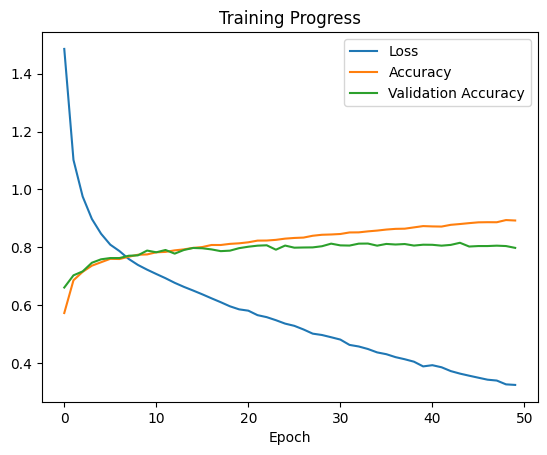

In [14]:
plt.figure()


plt.plot(train_losses, label="Loss")
plt.plot(train_accs, label="Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.legend()
plt.title("Training Progress")
plt.xlabel("Epoch")

plt.show()




In [22]:
input = lineToTensor('Vladimir').unsqueeze(0)
lengths = torch.tensor([input.shape[1]])
input = input.to(device)
lengths = lengths.to(device)

output = model(input, lengths)
print(output)
print(label_from_output(output, alldata.labels_uniq))

tensor([[-1.0634e+01, -9.1861e+00, -1.5852e+01, -9.7585e-04, -7.7461e+00,
         -9.2925e+00, -1.4621e+01, -1.8420e+01, -1.1948e+01, -1.5723e+01,
         -1.6326e+01, -8.1051e+00, -1.2592e+01, -1.3152e+01, -1.8300e+01,
         -1.1571e+01, -1.5894e+01, -1.6455e+01]], device='cuda:0',
       grad_fn=<LogSoftmaxBackward0>)
('Russian', 3)
